### **Q1.** Load clean q1_clean: https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv 

The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighborhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighborhood `; which borough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighborhood `.
2. Regress price on `Neighborhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multiple linear regression works.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
# load dataset
path = 'https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv'
df = pd.read_csv(path)

In [3]:
df.columns = [c.strip().replace(' ', '_') for c in df.columns]

In [4]:
df.describe()

,Price,Review_Scores_Rating
count,22153.000000,22153.000000
mean,154.787388,91.993093
std,148.843320,8.850658
min,10.000000,20.000000
25%,85.000000,89.000000
50%,125.000000,94.000000
75%,190.000000,100.000000
max,10000.000000,100.000000


In [5]:
# distribution of price by neighborhood

nb_stats = df.groupby('Neighbourhood')[['Price', 'Review_Scores_Rating']].mean()
print("Average Price and Scores by Neighborhood:")
print(nb_stats.sort_values(by='Price', ascending=False))

Average Price and Scores by Neighborhood:
                    Price  Review_Scores_Rating
Neighbourhood                                  
Manhattan      183.664286             91.801496
Staten Island  146.166667             90.843750
Brooklyn       127.747378             92.363497
Queens          96.857233             91.549057
Bronx           75.276498             91.654378


Manhattan is the most expensive borough.

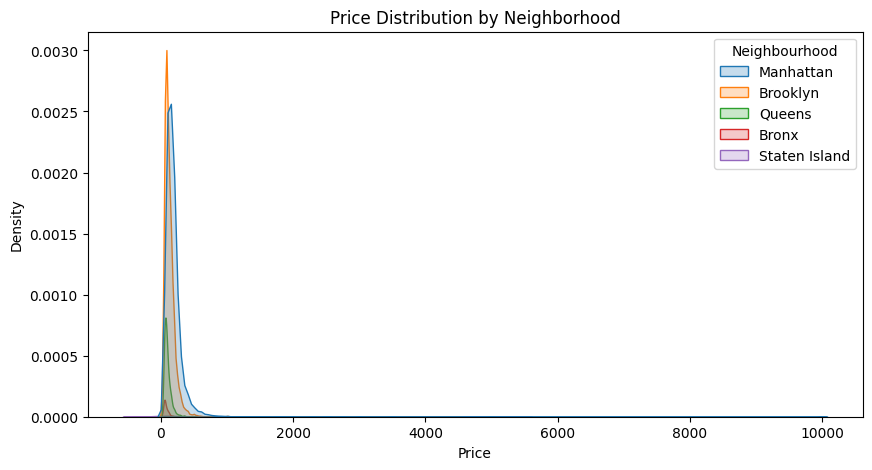

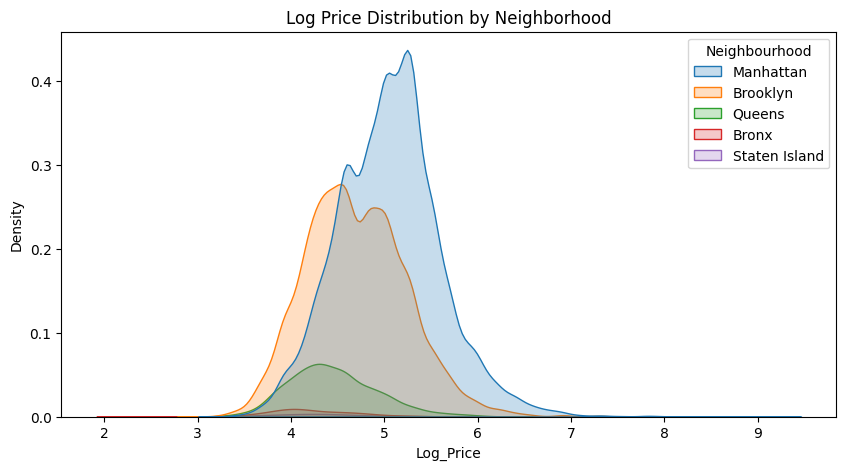

In [6]:
# KDE Plots
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='Price', hue='Neighbourhood', fill=True)
plt.title("Price Distribution by Neighborhood")
plt.show()

df['Log_Price'] = np.log1p(df['Price'])
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='Log_Price', hue='Neighbourhood', fill=True)
plt.title("Log Price Distribution by Neighborhood")
plt.show()

In [7]:
# model with no intercept

X_no_int = pd.get_dummies(df['Neighbourhood'])
y = df['Price']
reg_no_int = LinearRegression(fit_intercept=False).fit(X_no_int, y)
print("Coefficients (No Intercept):", X_no_int.columns, reg_no_int.coef_)

Coefficients (No Intercept): Index(['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island'], dtype='str') [ 75.2764977  127.74737834 183.66428632  96.8572327  146.16666667]


The coefficients equal the mean price for each neighborhood I found earlier. When there is no intercept the coefficients equal the means of each variable. 

In [8]:
# model with intercept

X_int = pd.get_dummies(df['Neighbourhood'], drop_first=True)
reg_int = LinearRegression().fit(X_int, y)
print("\nIntercept (Reference Neighbourhood):", reg_int.intercept_)
print("Coefficients (Difference from Reference):", X_int.columns, reg_int.coef_)


Intercept (Reference Neighbourhood): 75.27649769585331
Coefficients (Difference from Reference): Index(['Brooklyn', 'Manhattan', 'Queens', 'Staten Island'], dtype='str') [ 52.47088065 108.38778863  21.58073501  70.89016897]


When handling encoding this time, one category must be dropped to avoid the dummy variable trap.  
The intercept is the mean price of the borough dropped: Bronx.  
The coefficients are the difference in price between the Bronx and the borough being looked at.  
The coefficients from part 2 can be obtained by adding the intercept from this part to the coefficients.

In [9]:
# model with Review_Scores_Rating and Neighbourhood

X4 = pd.get_dummies(df[['Review_Scores_Rating', 'Neighbourhood']], drop_first=True)
y = df['Price']

# Split 80/20
X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y, test_size=0.2, random_state=40)

# Train Model
model4 = LinearRegression()
model4.fit(X4_train, y4_train)

# Evaluate
preds4 = model4.predict(X4_test)
r2_4 = r2_score(y4_test, preds4)
rmse_4 = np.sqrt(mean_squared_error(y4_test, preds4))

print(f"R² Score: {r2_4}")
print(f"RMSE: {rmse_4}")
print(f"Coefficient for Review Scores: {model4.coef_[0]}")

R² Score: 0.08230721172544131
RMSE: 106.28986886521714
Coefficient for Review Scores: 1.0275091578504976


In [10]:
# model with Review_Scores_Rating, Neighbourhood, and Property_Type

X5 = pd.get_dummies(df[['Review_Scores_Rating', 'Neighbourhood', 'Property_Type']], drop_first=True)

# Split 80/20
X5_train, X5_test, y5_train, y5_test = train_test_split(X5, y, test_size=0.2, random_state=40)

# Train Model
model5 = LinearRegression()
model5.fit(X5_train, y5_train)

# Evaluate
preds5 = model5.predict(X5_test)
r2_5 = r2_score(y5_test, preds5)
rmse_5 = np.sqrt(mean_squared_error(y5_test, preds5))

print(f"R² Score: {r2_5}")
print(f"RMSE: {rmse_5}")
print(f"Coefficient for Review Scores: {model5.coef_[0]}")

# To find the most expensive property type
prop_coefs = pd.Series(model5.coef_, index=X5.columns)
print("Top 3 most expensive property type coefficients:")
print(prop_coefs.filter(like='Property_Type').sort_values(ascending=False).head(3))

R² Score: 0.08534318021973553
RMSE: 106.11390582635056
Coefficient for Review Scores: 1.0168113684216333
Top 3 most expensive property type coefficients:
Property_Type_Condominium    102.506874
Property_Type_Townhouse       86.586869
Property_Type_Boat            81.364502
dtype: float64


The change in the review scores coefficient indicates that it was taking on credit for the fact that an expensive property had a higher price. Thus, when property types were introduced, the coefficient reduced slightly showing it had a smaller impact on the price than initially anticipated.